# Week2 任务三：分类验证与描述性分析

## Yunxi 产出说明
- 输入：`Processed_Data/main_perf_merged_all.xlsx`（任务二产出主表，包含 `is_popular`、`source` 等字段）。
- 本任务产出：
  1. 描述性统计：爆款/非爆款两组在核心指标上的 `count/mean/median/q25/q75/min/max`；
  2. 图表：箱线图（分布差异）+ 柱状图（均值/中位数对比）；
  3. 交付表：`K7直播间短视频分析表.xlsx`。
- 交付成果目录：`Deliverables/week2_task3/`，图表存放在 `Deliverables/week2_task3/figures/`。


In [2]:
from __future__ import annotations

import hashlib
import re
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

def find_project_root(start: Path) -> Path:
    """Walk upwards until Processed_Data exists."""
    cur = start.resolve()
    for _ in range(12):
        if (cur / "Processed_Data").exists():
            return cur
        if cur.parent == cur:
            break
        cur = cur.parent
    return start.resolve()

ROOT = find_project_root(Path.cwd())
INPUT_XLSX = ROOT / "Processed_Data" / "main_perf_merged_all.xlsx"
OUTDIR = ROOT / "Deliverables" / "week2_task3"
FIGDIR = OUTDIR / "figures"

OUTDIR.mkdir(parents=True, exist_ok=True)
FIGDIR.mkdir(parents=True, exist_ok=True)

# macOS 优先选用中文字体，避免图中中文乱码
plt.rcParams["font.sans-serif"] = ["PingFang SC", "Arial Unicode MS", "Noto Sans CJK SC", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

def safe_filename(name: str) -> str:
    """ASCII-friendly, stable, and unique for Chinese metric names."""
    raw = name.strip()
    normalized = re.sub(r"[\/:\s]+", "_", raw)
    ascii_part = re.sub(r"[^A-Za-z0-9_]+", "", normalized)
    h = hashlib.md5(raw.encode("utf-8")).hexdigest()[:8]
    return f"{ascii_part}_{h}" if ascii_part else f"metric_{h}"

print("ROOT:", ROOT)
print("INPUT:", INPUT_XLSX)
print("OUTDIR:", OUTDIR)
print("FIGDIR:", FIGDIR)


ROOT: /Users/bytedance/jinyun/KINYO_Project
INPUT: /Users/bytedance/jinyun/KINYO_Project/Processed_Data/main_perf_merged_all.xlsx
OUTDIR: /Users/bytedance/jinyun/KINYO_Project/Deliverables/week2_task3
FIGDIR: /Users/bytedance/jinyun/KINYO_Project/Deliverables/week2_task3/figures


In [3]:
# 2) 读取主表 & 基础分布检查
if not INPUT_XLSX.exists():
    raise FileNotFoundError(f"Missing input: {INPUT_XLSX}")

df = pd.read_excel(INPUT_XLSX)
display(df.head(3))

print("rows:", len(df), "cols:", df.shape[1])
if "is_popular" not in df.columns:
    raise ValueError("Expected column `is_popular` in merged table.")

df["is_popular"] = pd.to_numeric(df["is_popular"], errors="coerce").fillna(0).astype(int)
df["is_popular_label"] = df["is_popular"].map({0: "非爆款", 1: "爆款"}).fillna("未知")

print("is_popular value counts:")
display(df["is_popular"].value_counts(dropna=False))

if "source" in df.columns:
    print("source x is_popular_label:")
    display(pd.crosstab(df["source"], df["is_popular_label"]))


,素材ID,素材创建时间,datestamp,素材名称,素材标签,素材时长,素材类型,素材来源,点击率,转化率,...,attention_score,promotion_score,is_popular,source,素材评估,整体展现次数,整体点击次数,整体千次展现费用,normalized_name,is_pop_match_mv
0,7416214849771274240,2024-09-20 14:15:34,2024-09-23,老婆瞒着我在家唱歌，被震惊了！,"['k歌音响 ', '移动ktv ', '超大屏幕 ', '无线麦克风']",32,0.0,1,0.00,0.00,...,5.0,4.0,0,dy,NaN,NaN,NaN,NaN,NaN,NaN
1,7416347344670818304,2024-09-20 14:15:34,2024-09-23,全新升级的K歌蓝牙音响，搭配两支无线麦克风让你唱歌方便！,"['蓝牙音箱 ', '数码产品 ', '移动KTV ', '无线麦克风']",36,0.0,1,0.00,0.00,...,3.0,3.0,0,dy,NaN,NaN,NaN,NaN,NaN,NaN
2,7415824807521189888,2024-09-18 13:18:12,2024-09-23,老婆又瞒着我偷偷在家唱K！,"['好物推荐🔥 ', '蓝牙音箱 ', '数码产品 ', '唱歌']",30,0.0,1,13.26,1.62,...,5.0,4.0,0,dy,NaN,NaN,NaN,NaN,NaN,NaN


rows: 13856 cols: 83
is_popular value counts:


is_popular
0    11961
1     1895
Name: count, dtype: int64

source x is_popular_label:


is_popular_label,爆款,非爆款
source,,
dy,1752,10786
k7,143,1175


## 指标选择说明
- 任务二中 `is_popular` 的构建规则直接使用了 `消耗/点击率/转化率`，因此这三项在两组上的差异属于规则内生。
- 任务三的“分类验证”更建议优先看未直接参与打标的指标：如播放/互动/GMV/直播间行为等。


In [4]:
# 3) 指标字段准备（数值化）
def coerce_numeric(s: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(s):
        return s
    s2 = s.astype(str).str.strip()
    s2 = s2.replace({"nan": pd.NA, "None": pd.NA, "": pd.NA})
    s2 = s2.str.replace(",", "", regex=False)
    pct_mask = s2.str.endswith("%", na=False)
    s_num = pd.to_numeric(s2.str.replace("%", "", regex=False), errors="coerce")
    s_num[pct_mask] = s_num[pct_mask] / 100.0
    return s_num

def available_cols(df: pd.DataFrame, cols: Iterable[str]) -> list[str]:
    return [c for c in cols if c in df.columns]

label_metrics = ["消耗", "点击率", "转化率"]
validate_metrics = [
    "播放数", "有效播放数",
    "点赞次数", "评论次数", "分享次数",
    "展示次数", "点击次数", "转化数",
    "直接成交金额", "直接成交订单数", "直接支付ROI",
    "直接下单金额", "直接下单订单数",
    "直播间观看人次", "直播间商品点击次数", "直播间评论次数", "直播间分享次数",
    "素材ARPU",
]

metrics = available_cols(df, label_metrics + validate_metrics)
print("metrics used:", metrics)

for c in metrics:
    df[c] = coerce_numeric(df[c])

display(df[["is_popular_label"] + metrics].head(3))


metrics used: ['消耗', '点击率', '转化率', '播放数', '有效播放数', '点赞次数', '评论次数', '分享次数', '展示次数', '点击次数', '转化数', '直接成交金额', '直接成交订单数', '直接支付ROI', '直接下单金额', '直接下单订单数', '直播间观看人次', '直播间商品点击次数', '直播间评论次数', '直播间分享次数', '素材ARPU']


,is_popular_label,消耗,点击率,转化率,播放数,有效播放数,点赞次数,评论次数,分享次数,展示次数,...,直接成交金额,直接成交订单数,直接支付ROI,直接下单金额,直接下单订单数,直播间观看人次,直播间商品点击次数,直播间评论次数,直播间分享次数,素材ARPU
0,非爆款,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,非爆款,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,非爆款,159.5,13.26,1.62,1229.0,303.0,4.0,0.0,0.0,2323.0,...,755.0,5.0,5.3,924.0,6.0,457.0,30.0,25.0,0.0,159.5


In [5]:
# 4) 描述性统计：按 is_popular 分组
def describe_by_group(df: pd.DataFrame, group_cols: list[str], metrics: list[str]) -> pd.DataFrame:
    rows = []
    for m in metrics:
        x = df[group_cols + [m]].dropna(subset=[m])
        def q(p: float):
            return lambda s: s.quantile(p)
        agg = x.groupby(group_cols)[m].agg(
            count="count",
            mean="mean",
            median="median",
            q25=q(0.25),
            q75=q(0.75),
            min="min",
            max="max",
        )
        agg.insert(0, "metric", m)
        rows.append(agg.reset_index())
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

overall_stats = describe_by_group(df, ["is_popular"], metrics)
display(overall_stats.head(30))


,is_popular,metric,count,mean,median,q25,q75,min,max
0,0,消耗,11961,277.892506,8.880,0.00,79.3900,0.00,175636.77
1,1,消耗,1895,5475.450422,2367.970,1118.35,6084.3050,540.72,147942.30
2,0,点击率,11961,5.979363,3.840,0.00,7.4100,0.00,100.00
3,1,点击率,1895,5.514185,4.200,3.27,5.5300,1.21,77.76
4,0,转化率,11961,0.941037,0.000,0.00,0.9300,0.00,100.00
5,1,转化率,1895,2.854923,2.800,2.23,3.4750,0.16,7.06
6,0,播放数,10786,5125.490821,74.000,0.00,792.7500,0.00,1089254.00
7,1,播放数,1752,79136.527968,31928.000,13440.50,88407.7500,1345.00,909680.00
8,0,有效播放数,10786,900.486464,23.000,0.00,238.0000,0.00,177875.00
9,1,有效播放数,1752,17484.470320,7193.000,3214.00,20075.2500,637.00,421182.00


In [6]:
# 5) 描述性统计：按 source + is_popular 分组（用于对照 dy/k7）
if "source" in df.columns:
    by_source_stats = describe_by_group(df, ["source", "is_popular"], metrics)
    display(by_source_stats.head(30))
else:
    by_source_stats = pd.DataFrame()
    print("No `source` column; skip.")


,source,is_popular,metric,count,mean,median,q25,q75,min,max
0,dy,0,消耗,10786,246.623394,7.050,0.0000,71.6450,0.00,43921.63
1,dy,1,消耗,1752,5409.168807,2337.205,1080.3325,6075.7350,540.72,147942.30
2,k7,0,消耗,1175,564.929651,37.420,3.6500,156.0200,0.00,175636.77
3,k7,1,消耗,143,6287.516084,2783.340,1472.6950,6206.7250,883.81,66624.88
4,dy,0,点击率,10786,5.897118,3.575,0.0000,7.1500,0.00,100.00
5,dy,1,点击率,1752,5.548196,4.160,3.2300,5.4700,1.21,77.76
6,k7,0,点击率,1175,6.734340,5.560,3.1100,8.5850,0.00,100.00
7,k7,1,点击率,143,5.097483,4.920,3.8700,6.2650,1.38,12.53
8,dy,0,转化率,10786,0.965026,0.000,0.0000,0.9700,0.00,100.00
9,dy,1,转化率,1752,2.925308,2.860,2.3275,3.5300,0.16,7.06


In [8]:
# 6) 简单效应汇总：爆款 vs 非爆款（均值/中位数比值）
def effect_summary(overall_stats: pd.DataFrame) -> pd.DataFrame:
    if overall_stats.empty or "is_popular" not in overall_stats.columns:
        return overall_stats
    base = overall_stats.pivot_table(
        index="metric",
        columns="is_popular",
        values=["count", "mean", "median", "q25", "q75"],
        aggfunc="first",
    )
    base.columns = [f"{a}_{'popular' if b == 1 else 'non_popular'}" for a, b in base.columns]
    base = base.reset_index()
    def add_diff_ratio(name: str) -> None:
        a = f"{name}_popular"
        b = f"{name}_non_popular"
        if a in base.columns and b in base.columns:
            base[f"{name}_diff"] = base[a] - base[b]
            base[f"{name}_ratio"] = base[a] / base[b].replace({0: pd.NA})
    add_diff_ratio("mean")
    add_diff_ratio("median")
    add_diff_ratio("q75")
    return base

effects = effect_summary(overall_stats)
effects_small = effects[effects["metric"].isin(available_cols(df, validate_metrics))].copy()
keep_cols = [
    "metric",
    "median_non_popular", "median_popular", "median_ratio",
    "mean_non_popular", "mean_popular", "mean_ratio",
]
keep_cols = [c for c in keep_cols if c in effects_small.columns]
effects_small = effects_small[keep_cols]
for c in ["median_ratio", "mean_ratio", "median_non_popular", "median_popular", "mean_non_popular", "mean_popular"]:
    if c in effects_small.columns:
        effects_small[c] = pd.to_numeric(effects_small[c], errors="coerce").round(3)
display(effects_small)


,metric,median_non_popular,median_popular,median_ratio,mean_non_popular,mean_popular,mean_ratio
0,分享次数,0.00,9.000,NaN,1.079,22.711,21.041
1,展示次数,95.00,31126.000,327.642,4748.169,73321.751,15.442
2,播放数,74.00,31928.000,431.459,5125.491,79136.528,15.440
3,有效播放数,23.00,7193.000,312.739,900.486,17484.470,19.417
5,点击次数,6.00,1459.500,243.250,232.072,2939.530,12.666
7,点赞次数,0.00,61.000,NaN,11.828,153.961,13.017
8,直接下单订单数,0.00,48.000,NaN,4.690,107.951,23.020
9,直接下单金额,0.00,8160.000,NaN,809.584,18496.947,22.847
10,直接成交订单数,0.00,37.000,NaN,3.450,84.834,24.589
11,直接成交金额,0.00,6373.595,NaN,576.279,14293.280,24.803


## 图表


In [ ]:
# 7) 画箱线图 + 柱状图
def plot_metric(metric: str, log1p: bool = False) -> None:
    if metric not in df.columns:
        print(f"skip: missing column {metric}")
        return
    plot_df = df[["is_popular_label", metric]].dropna(subset=[metric]).copy()
    if plot_df.empty:
        print(f"skip: empty after dropna for {metric}")
        return

    safe = safe_filename(metric)
    box_path = FIGDIR / f"box_{safe}.png"
    bar_path = FIGDIR / f"bar_{safe}.png"

    # Boxplot
    y_col = metric
    y_label = metric
    if log1p:
        plot_df["_log1p"] = np.log1p(plot_df[metric].clip(lower=0))
        y_col = "_log1p"
        y_label = f"log1p({metric})"
    plt.figure(figsize=(6, 4))
    ax = sns.boxplot(data=plot_df, x="is_popular_label", y=y_col, order=["非爆款", "爆款"], showfliers=False)
    ax.set_xlabel("")
    ax.set_ylabel(y_label)
    ax.set_title(f"{metric} 分布对比（箱线图）")
    plt.tight_layout()
    plt.savefig(box_path, dpi=200)
    plt.show()
    plt.close()

    # Barplot
    agg = plot_df.groupby("is_popular_label")[metric].agg(mean="mean", median="median").reindex(["非爆款", "爆款"])
    agg = agg.reset_index()
    melted = agg.melt(id_vars="is_popular_label", var_name="stat", value_name="value")
    plt.figure(figsize=(6, 4))
    ax = sns.barplot(data=melted, x="is_popular_label", y="value", hue="stat", order=["非爆款", "爆款"])
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} 均值/中位数对比（柱状图）")
    plt.tight_layout()
    plt.savefig(bar_path, dpi=200)
    plt.show()
    plt.close()

    print("saved:", box_path.relative_to(ROOT))
    print("saved:", bar_path.relative_to(ROOT))


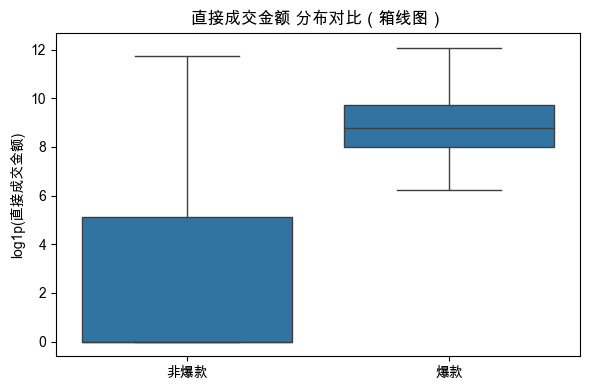

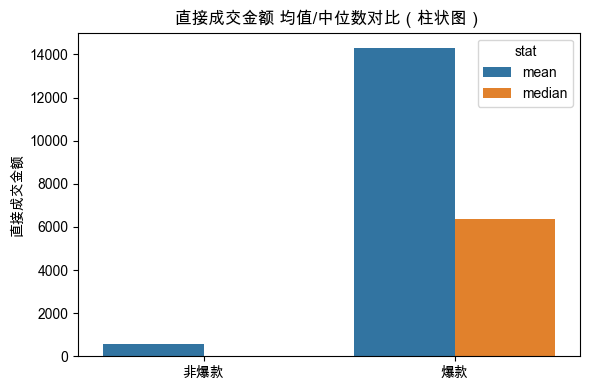

saved: Deliverables/week2_task3/figures/box_metric_3d0bc096.png
saved: Deliverables/week2_task3/figures/bar_metric_3d0bc096.png


In [10]:
# 8) 图表：直接成交金额
plot_metric("直接成交金额", log1p=True)


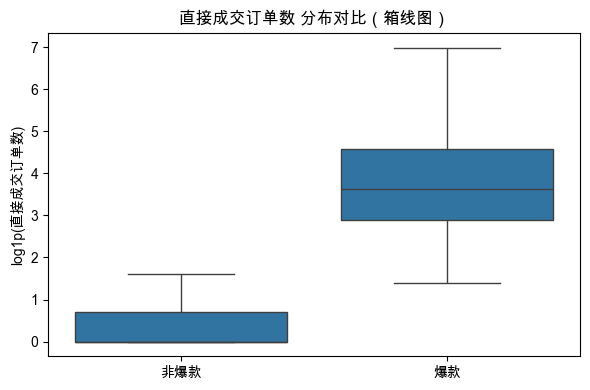

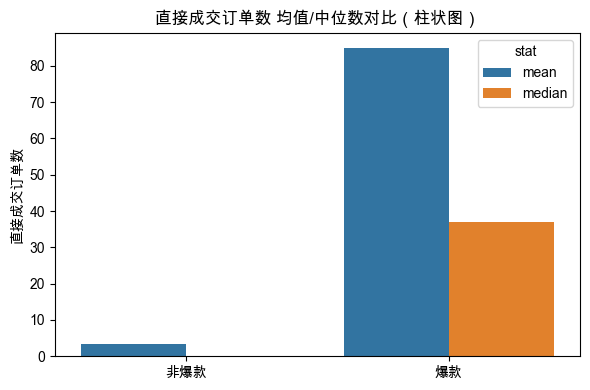

saved: Deliverables/week2_task3/figures/box_metric_258c04c8.png
saved: Deliverables/week2_task3/figures/bar_metric_258c04c8.png


In [21]:
# 8) 直接成交订单数
plot_metric("直接成交订单数", log1p=True)


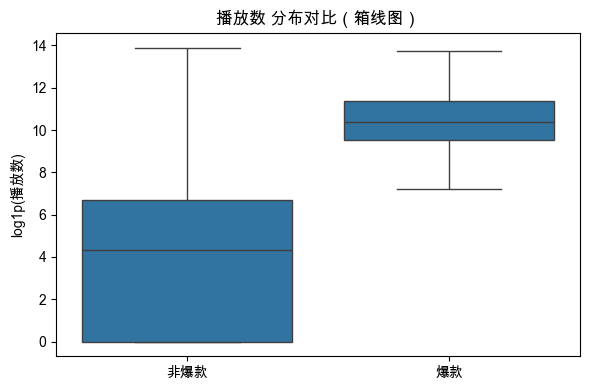

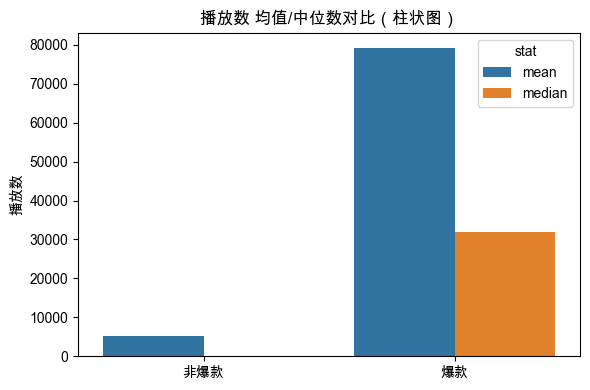

saved: Deliverables/week2_task3/figures/box_metric_b9302462.png
saved: Deliverables/week2_task3/figures/bar_metric_b9302462.png


In [ ]:
# 8) 播放数
plot_metric("播放数", log1p=True)


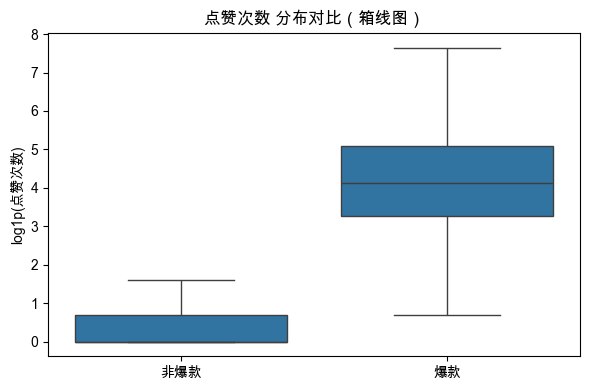

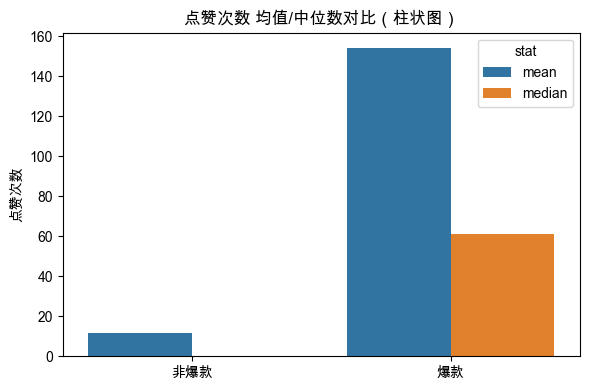

saved: Deliverables/week2_task3/figures/box_metric_a1a1870d.png
saved: Deliverables/week2_task3/figures/bar_metric_a1a1870d.png


In [ ]:
# 8) 点赞次数
plot_metric("点赞次数", log1p=True)


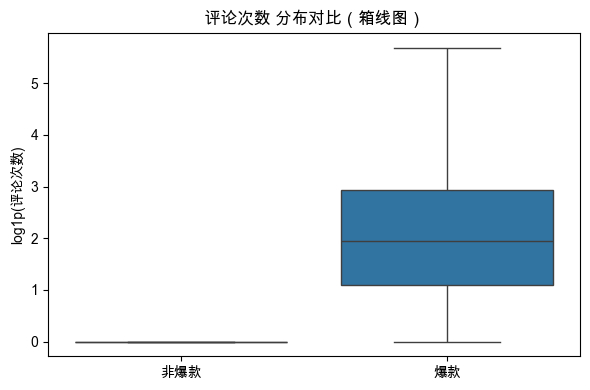

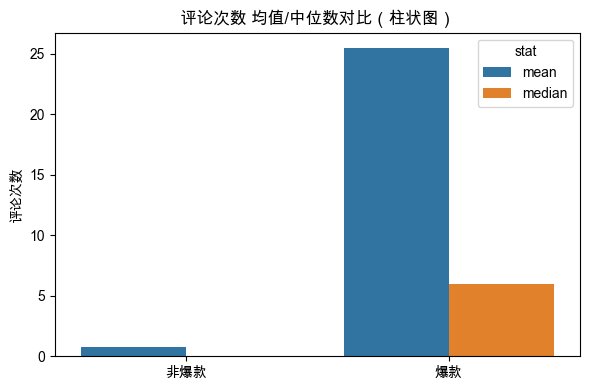

saved: Deliverables/week2_task3/figures/box_metric_3d54b4f7.png
saved: Deliverables/week2_task3/figures/bar_metric_3d54b4f7.png


In [ ]:
# 8) 评论次数
plot_metric("评论次数", log1p=True)


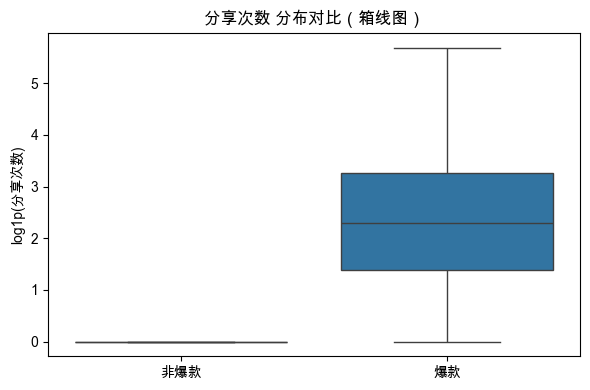

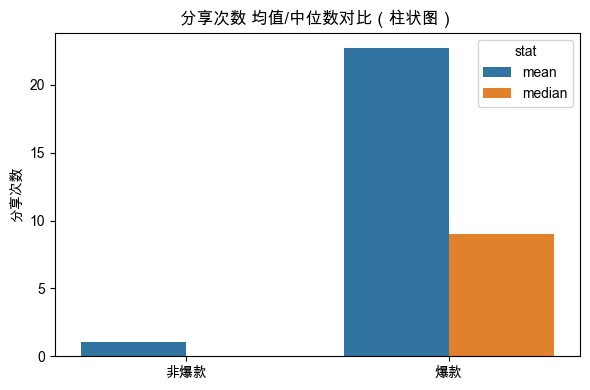

saved: Deliverables/week2_task3/figures/box_metric_76dc0874.png
saved: Deliverables/week2_task3/figures/bar_metric_76dc0874.png


In [ ]:
# 8) 分享次数
plot_metric("分享次数", log1p=True)


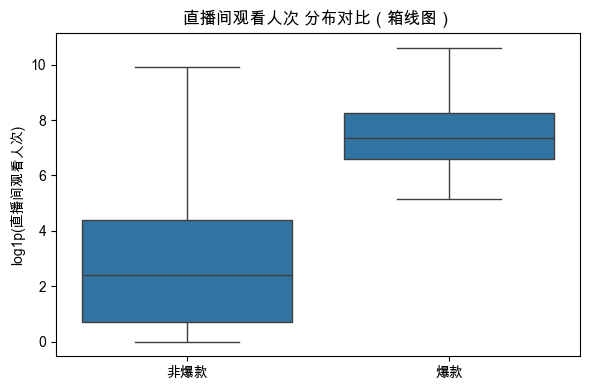

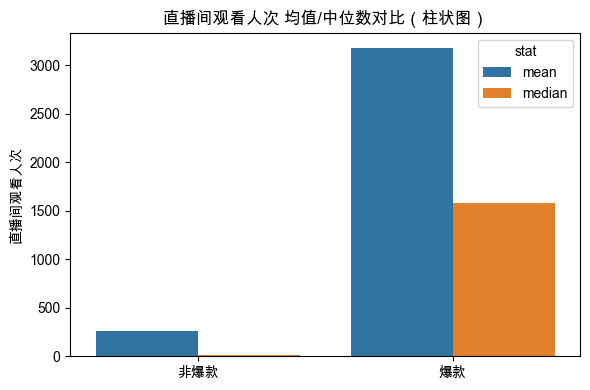

saved: Deliverables/week2_task3/figures/box_metric_b7fbac10.png
saved: Deliverables/week2_task3/figures/bar_metric_b7fbac10.png


In [ ]:
# 8) 直播间观看人次
plot_metric("直播间观看人次", log1p=True)


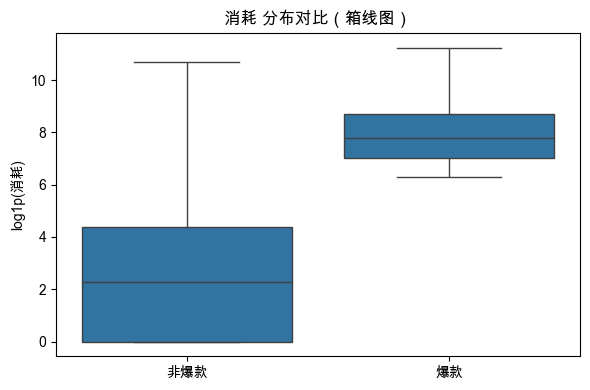

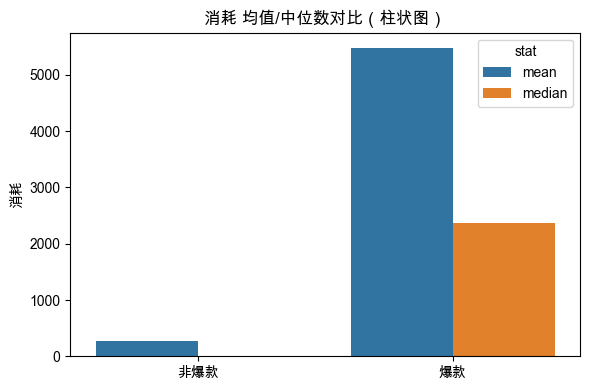

saved: Deliverables/week2_task3/figures/box_metric_4ab855fb.png
saved: Deliverables/week2_task3/figures/bar_metric_4ab855fb.png


In [ ]:
# 8) 消耗
plot_metric("消耗", log1p=True)


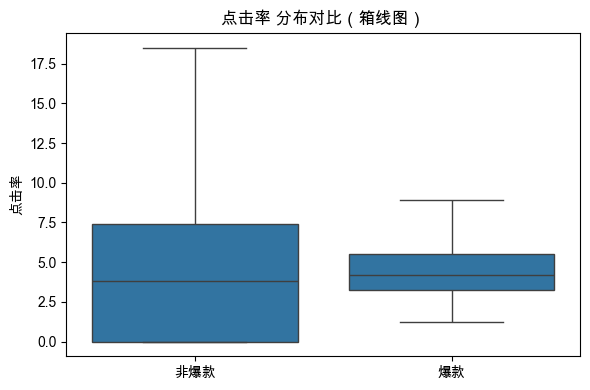

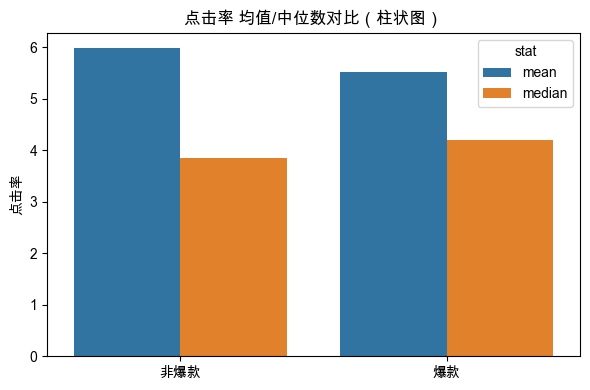

saved: Deliverables/week2_task3/figures/box_metric_e6867bb9.png
saved: Deliverables/week2_task3/figures/bar_metric_e6867bb9.png


In [ ]:
# 8) 点击率
plot_metric("点击率", log1p=False)


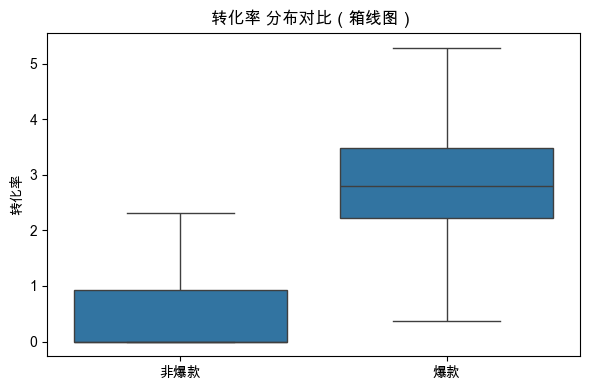

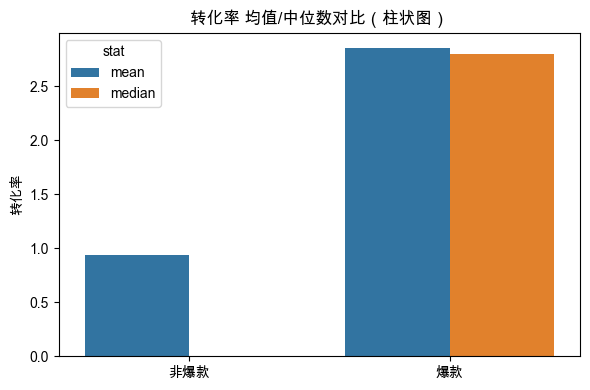

saved: Deliverables/week2_task3/figures/box_metric_71505437.png
saved: Deliverables/week2_task3/figures/bar_metric_71505437.png


In [ ]:
# 8) 转化率
plot_metric("转化率", log1p=False)


## 交付成果
- 交付表：`K7直播间短视频分析表.xlsx`（含 `is_popular` 标签与其它字段）。
- 描述统计：`task3_descriptive_stats.xlsx`（overall / by_source / effect_summary）。


In [20]:
# 9) 导出 deliverables（表格）
analysis_table_path = OUTDIR / "K7直播间短视频分析表.xlsx"
analysis_table_path_ascii = OUTDIR / "K7_short_video_analysis_table.xlsx"
stats_path = OUTDIR / "task3_descriptive_stats.xlsx"

df.to_excel(analysis_table_path, index=False)
df.to_excel(analysis_table_path_ascii, index=False)

with pd.ExcelWriter(stats_path, engine="openpyxl") as writer:
    overall_stats.to_excel(writer, sheet_name="overall_by_is_popular", index=False)
    if not by_source_stats.empty:
        by_source_stats.to_excel(writer, sheet_name="by_source_and_is_popular", index=False)
    effects.to_excel(writer, sheet_name="effect_summary", index=False)

print("saved:", analysis_table_path.relative_to(ROOT))
print("saved:", analysis_table_path_ascii.relative_to(ROOT))
print("saved:", stats_path.relative_to(ROOT))


saved: Deliverables/week2_task3/K7直播间短视频分析表.xlsx
saved: Deliverables/week2_task3/K7_short_video_analysis_table.xlsx
saved: Deliverables/week2_task3/task3_descriptive_stats.xlsx
